# Full Demo - Financial Fraud Detection

Notebook trình bày pipeline HDFS → Spark → Machine Learning → Evaluation → Suspicious Transactions trong khoảng 7–10 phút. Các job nặng đã được chạy bằng `scripts/run_phase2.*` đến `run_phase5.*`; notebook load artifact thật để demo nhanh và có thể tái lập.

## 1. Kết nối Spark cluster và HDFS

Spark chạy ở chế độ standalone với hai worker. Nguồn dữ liệu chính sau upload luôn là HDFS.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('financial-fraud-full-demo').getOrCreate()
print('Spark:', spark.version)
print('Master:', spark.sparkContext.master)
spark.read.parquet('hdfs:///financial/_health/spark-smoke').count()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/26 10:18:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.9
Master: spark://spark-master:7077


2

## 2. Dataset, cleaning và class imbalance

Phase 2 dùng schema tường minh, xử lý null/duplicate, chuẩn hóa amount và timestamp, join nhãn rồi chuyển CSV thành Parquet.

In [2]:
phase2 = json.loads(Path('/workspace/output/results/phase2_summary.json').read_text(encoding='utf-8'))
labeled = spark.read.parquet('hdfs:///financial/processed/labeled_transactions')
labeled.printSchema()
labeled.select('transaction_id', 'transaction_time', 'amount', 'use_chip', 'mcc', 'class').show(5, truncate=False)
phase2['clean_profile']

root
 |-- transaction_id: long (nullable = true)
 |-- transaction_time: timestamp (nullable = true)
 |-- client_id: long (nullable = true)
 |-- card_id: long (nullable = true)
 |-- amount: double (nullable = true)
 |-- use_chip: string (nullable = true)
 |-- merchant_id: long (nullable = true)
 |-- merchant_city: string (nullable = true)
 |-- merchant_state: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- mcc: integer (nullable = true)
 |-- errors: string (nullable = true)
 |-- class: integer (nullable = true)
 |-- transaction_year: integer (nullable = true)

+--------------+-------------------+------+------------------+----+-----+
|transaction_id|transaction_time   |amount|use_chip          |mcc |class|
+--------------+-------------------+------+------------------+----+-----+
|18881537      |2017-01-01 00:50:00|9.58  |Chip Transaction  |5813|0    |
|18881544      |2017-01-01 00:56:00|197.53|Chip Transaction  |3722|0    |
|18881566      |2017-01-01 01:19:00|72.0  |Onli

{'clean_transaction_count': 13305915,
 'valid_label_count': 8914963,
 'labeled_transaction_count': 8914963,
 'transactions_without_training_label': 4390952,
 'label_join_coverage_percentage': 67.0,
 'class_distribution': {'0': {'count': 8901631, 'percentage': 99.850454},
  '1': {'count': 13332, 'percentage': 0.149546}},
 'amount_statistics': {'min': -500.0,
  'max': 6613.44,
  'mean': 42.94938717524695,
  'stddev': 81.52651870178052,
  'quartiles': [8.93, 28.99, 63.67]},
 'dropped_invalid_or_duplicate_transactions': 0}

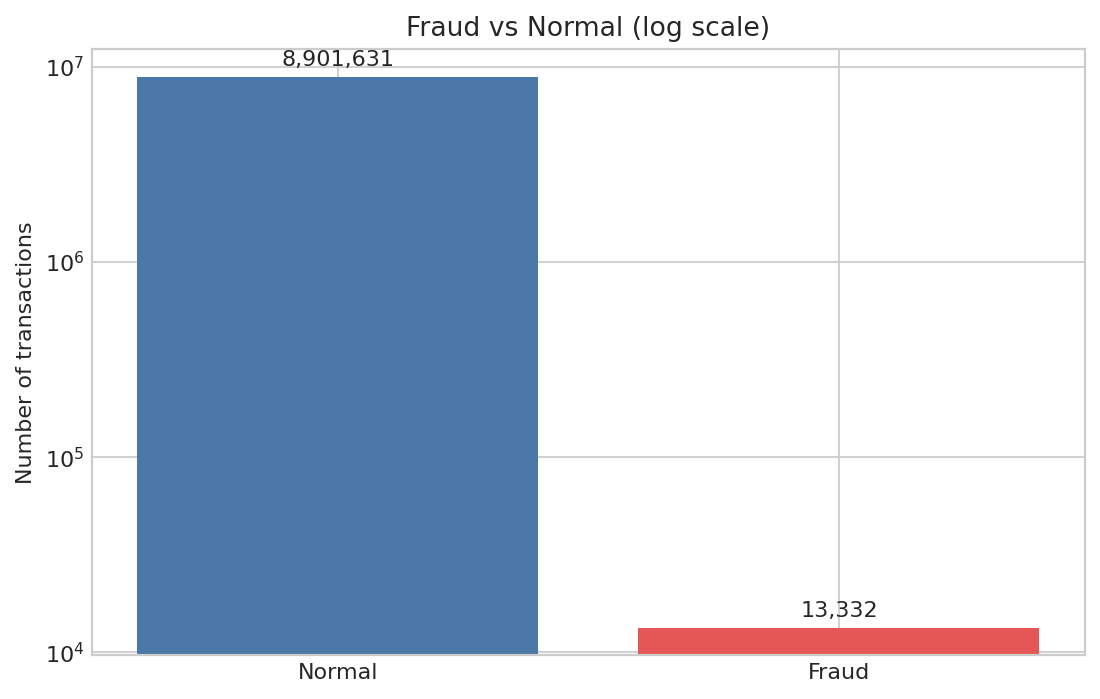

In [3]:
display(Image(filename='/workspace/output/figures/01_class_distribution.png'))

Fraud chỉ chiếm khoảng 0,15%, vì vậy Accuracy không đủ để đánh giá mô hình.

## 3. Feature Engineering, Train/Test và imbalance handling

Preprocessor chỉ fit trên Train. `Class` và các ID không nằm trong feature vector. Test giữ nguyên phân bố thực tế.

In [ ]:
phase3 = json.loads(Path('/workspace/output/results/phase3_summary.json').read_text(encoding='utf-8'))
pd.DataFrame({
    'split': ['Train', 'Test', 'RF undersampling Train'],
    'rows': [phase3['split']['train']['total'], phase3['split']['test']['total'], phase3['supervised_training']['undersampling']['distribution']['total']],
    'fraud': [phase3['split']['train']['classes']['1']['count'], phase3['split']['test']['classes']['1']['count'], phase3['supervised_training']['undersampling']['distribution']['classes']['1']['count']]
})

In [ ]:
{
    'feature_count': phase3['features']['count'],
    'class_in_features': phase3['features']['class_in_feature_vector'],
    'preprocessor_fit_scope': phase3['features']['preprocessor_fit_scope'],
    'test_was_sampled': phase3['split']['test_was_sampled']
}

## 4. Logistic Regression, Random Forest và Isolation Forest

Precision, Recall và F1 dưới đây đều dành cho `class = 1`. Isolation Forest không dùng Class khi fit; nhãn thật chỉ dùng sau anomaly scoring để đánh giá.

In [ ]:
comparison = pd.read_csv('/workspace/output/results/model_comparison.csv')
comparison[['model', 'imbalance_method', 'precision', 'recall', 'f1', 'pr_auc', 'accuracy']].round(4)

In [ ]:
display(Image(filename='/workspace/output/figures/05_metric_comparison.png'))
display(Image(filename='/workspace/output/figures/06_precision_recall_curve.png'))

## 5. Confusion Matrix và Threshold Analysis

Class weight tăng Recall nhưng có thể tạo rất nhiều False Positive. Threshold giảm thường tăng sensitivity; không chọn threshold nghiệp vụ khi chưa biết chi phí FP/FN.

In [ ]:
display(Image(filename='/workspace/output/figures/04_confusion_matrix.png'))
display(Image(filename='/workspace/output/figures/09_threshold_analysis.png'))

In [ ]:
thresholds = pd.read_csv('/workspace/output/results/threshold_analysis.csv')
thresholds.loc[thresholds.slug == 'rf_undersampling', ['threshold', 'precision', 'recall', 'f1', 'fp', 'fn']].round(4)

## 6. Suspicious Transactions

Các giao dịch dưới đây chỉ được gắn cờ `NEEDS_REVIEW`, không phải kết luận gian lận.

In [ ]:
suspicious = spark.read.parquet('hdfs:///financial/predictions/suspicious_transactions')
suspicious.select('transaction_id', 'transaction_time', 'amount', 'fraud_probability', 'status', 'actual_class').orderBy('fraud_probability', ascending=False).show(20, truncate=False)

## 7. Load model và dự đoán dữ liệu mới

`new_transactions.csv` đã được upload lên HDFS. Script load preprocessor và model đã lưu, không train lại và không yêu cầu cột Class.

In [6]:
new_predictions = spark.read.parquet('hdfs:///financial/predictions/new_transactions')
new_predictions.orderBy('fraud_probability', ascending=False).show(20, truncate=False)

+--------------+-------------------+------+------------------+----------+------------+----------------+---------+
|transaction_id|transaction_time   |amount|fraud_probability |prediction|status      |model           |threshold|
+--------------+-------------------+------+------------------+----------+------------+----------------+---------+
|9900000001    |2019-12-31 23:30:00|1500.0|0.5122375897503071|1         |NEEDS_REVIEW|rf_undersampling|0.5      |
+--------------+-------------------+------+------------------+----------+------------+----------------+---------+



## 8. Kết luận

Pipeline đã chứng minh dữ liệu nằm trên HDFS, xử lý bằng Spark, model có thể lưu/load lại, metric được tính trên Test không sampling và prediction được ghi trở lại HDFS. Bước triển khai thực tế tiếp theo cần threshold theo chi phí nghiệp vụ, monitoring drift và quy trình analyst review.